### Imputación KNN

### ¿Qué es la imputación KNN?

* La imputación `KNN (k-Nearest Neighbors)` es una técnica usada para rellenar valores faltantes `(missing values)` en conjuntos de datos.
* Se basa en el algoritmo de vecinos más cercanos (KNN), que es comúnmente usado en tareas de clasificación y regresión.
* La idea detrás de la imputación KNN es que `una instancia con valores faltantes puede "parecerse" a otras instancias completas`, por lo que podemos usar los valores de sus `k vecinos más cercanos (los más similares) para estimar y rellenar los datos que faltan`.

***¿Cómo funciona?***
1. Distancia entre instancias:
   - Para encontrar los vecinos más cercanos, `se calcula una medida de distancia (como la euclidiana)` entre la instancia con valores faltantes y otras instancias completas.
   - Solo se usan las columnas que no tienen valores faltantes en común para calcular esta distancia.
2. Búsqueda de vecinos (k vecinos más cercanos):
   - Se identifican `las k instancias más similares (vecinos más cercanos) al registro incompleto`.
3. Imputación para cada valor faltante:
   - Si es `numérico`, se puede usar el promedio (media) o mediana de los valores de los vecinos.
   - Si es `categórico`, se suele usar la moda (la categoría más frecuente entre los vecinos).

### Ejemplo práctico

* Imaginemos que tenemos esta serie de datos donde contamos con 3 caracterisitcas, edad, estudio e ingreso.
* Es decir, queremos analizar el ingreso de una persona en base a su edad y nivel de estudio.

***NOTAS***
* Cómo es una lista de listas de 3 componentes, al hacer esto representamos:
  - `datos.T[0]`: todas las edades
  - `datos.T[1]`: todos los niveles de estudio
  - `datos.T[2]`: todos ingresos declarados

Text(0.5, 0, 'Ingreso ($)')

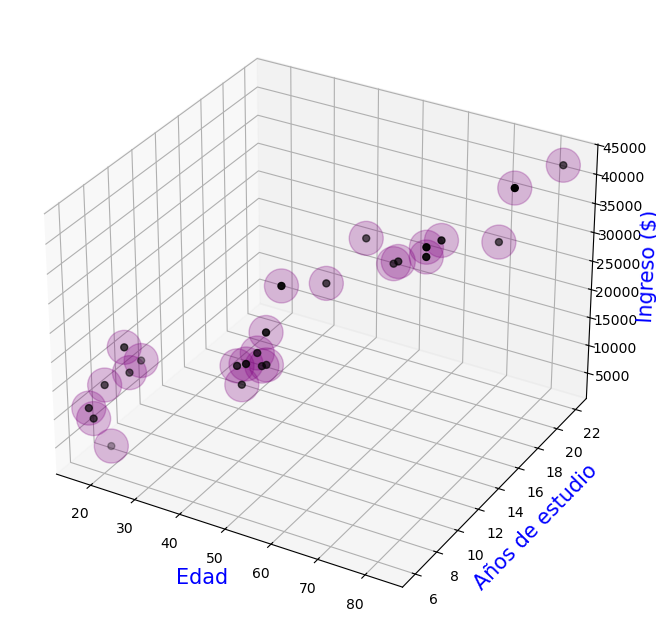

In [2]:
import numpy as np
import matplotlib.pyplot as plt

### Datos del contexto
edad = np.array([17, 18, 18, 19, 20,
                 21, 21, 40, 41, 42,
                 42, 43, 44, 44, 45,
                 50, 54, 60, 61, 67,
                 67, 68, 76, 79, 83])
estudio = np.array([6, 6, 7, 7, 8,
                    8, 9, 10, 10, 10, 
                    11, 11, 11, 11, 12,
                    14, 16, 16, 16, 16,
                    16, 17, 19, 19, 22])
ingreso = np.array([11230, 9624, 13798, 3215, 19169, 
                    14982, 15419, 17286, 14232, 18092,
                    18318, 16260, 22347, 16710, 28949,
                    27309, 32779, 29743, 30341, 34088,
                    32435, 33909, 32263, 42067, 42295])

### Unimos los 3 arrays para crear cada fila [edad, estudio, ingreso]
datos = np.stack((edad, estudio, ingreso), axis=1)


### Gráfiquemos estos datos para ver la relación
fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(1, 1, 1, projection="3d")

ax.scatter(datos.T[0], datos.T[1], datos.T[2],
           marker="o", c="purple", s=600, alpha=0.25)
ax.scatter(datos.T[0], datos.T[1], datos.T[2],
           marker=".", c="black", s=100)

ax.set_xlabel("Edad", fontsize=15, color="blue")
ax.set_ylabel("Años de estudio", fontsize=15, color="blue")
ax.set_zlabel("Ingreso ($)", fontsize=15, color="blue")


### Preprocesamiento de los Datos

* Estos datos no están escalados, por lo que debemos escalarlos.

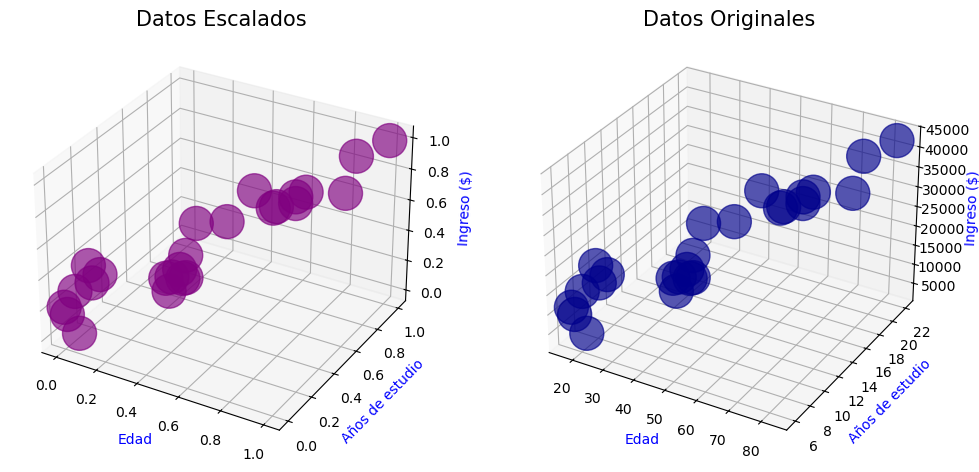

In [4]:
from sklearn import preprocessing

### Creamos una instancia del escalador y escalamos los datos.
escalador = preprocessing.MinMaxScaler()
escalados = escalador.fit_transform(datos)

### Gráfica tridimensional de los datos escalados y originales
fig = plt.figure(figsize=(12, 12))

### Creamos el promer grafico
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.scatter(escalados.T[0], 
           escalados.T[1], 
           escalados.T[2],
           marker="o", c="purple", s=600, alpha=0.65)

ax.set_title("Datos Escalados", fontsize=15)
ax.set_xlabel("Edad", fontsize=10, color="blue")
ax.set_ylabel("Años de estudio", fontsize=10, color="blue")
ax.set_zlabel("Ingreso ($)", fontsize=10, color="blue")

### Creamos el segundo grafico
ax = fig.add_subplot(1, 2, 2, projection="3d")
ax.scatter(datos.T[0], 
           datos.T[1], 
           datos.T[2],
           marker="o", c="darkblue", s=600, alpha=0.65)

ax.set_title("Datos Originales", fontsize=15)
ax.set_xlabel("Edad", fontsize=10, color="blue")
ax.set_ylabel("Años de estudio", fontsize=10, color="blue")
ax.set_zlabel("Ingreso ($)", fontsize=10, color="blue")

plt.show()
originales = escalados

### Introducción de datos faltantes

* Introduzcamos unos faltantes para poder hacer la imputación.

In [8]:
### Faltantes contendrá [edad, estudio, ingreso]
faltantes = escalados.copy()

### En las filas indice 2, 7, 12, 17, 22 de la tercera columna asignamos nan
faltantes[[2, 7, 12, 17, 22], 2] = np.nan
faltantes

array([[0.        , 0.        , 0.20509212],
       [0.01515152, 0.        , 0.16399693],
       [0.01515152, 0.0625    ,        nan],
       [0.03030303, 0.0625    , 0.        ],
       [0.04545455, 0.125     , 0.40823951],
       [0.06060606, 0.125     , 0.30110031],
       [0.06060606, 0.1875    , 0.3122825 ],
       [0.34848485, 0.25      ,        nan],
       [0.36363636, 0.25      , 0.2819089 ],
       [0.37878788, 0.25      , 0.38068066],
       [0.37878788, 0.3125    , 0.38646366],
       [0.39393939, 0.3125    , 0.33380246],
       [0.40909091, 0.3125    ,        nan],
       [0.40909091, 0.3125    , 0.3453173 ],
       [0.42424242, 0.375     , 0.65849539],
       [0.5       , 0.5       , 0.61653019],
       [0.56060606, 0.625     , 0.75649949],
       [0.65151515, 0.625     ,        nan],
       [0.66666667, 0.625     , 0.69411464],
       [0.75757576, 0.625     , 0.78999488],
       [0.75757576, 0.625     , 0.74769703],
       [0.77272727, 0.6875    , 0.78541453],
       [0.

### Estimación e Imputación de datos faltantes

* Para usar el KNN Imputer hay mandar a llamar a su librería `from sklearn.imputer import KNNImputer`.
* ***¿Porque se le tienen que asignar pesos?***
  - La opción weights en `KNNImputer` de scikit-learn controla cómo se ponderan los vecinos a la hora de imputar un valor faltante. Es decir, `cómo influye cada vecino en la estimación del valor faltante`.
  - Cuando se imputan valores usando vecinos, `no todos los vecinos son igual de "buenos"`. Algunos están más cerca (son más parecidos), por lo tanto, es razonable darles más peso en la imputación. `Esto es especialmente importante cuando hay variabilidad entre los vecinos`.

***Tipos de Pesos***
1. `weights="uniform"` (uniforme)
   - Todos los vecinos tienen el `mismo peso`.
   - La imputación se hace tomando la media o moda simple de los valores de los vecinos.
   - Ejemplo: Si los vecinos tienen edades [25, 30, 35], la imputación sería (25 + 30 + 35) / 3 = 30.

2. `weights="distance"` (basado en distancia)
   - Los vecinos `más cercanos tienen mayor peso`.
   - Se usa una media ponderada donde los vecinos más parecidos (menor distancia) influyen más en la imputación.
   - `Esto puede mejorar la precisión cuando hay una gran diferencia entre vecinos`.

In [10]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5, weights="uniform")
imputados_uni = imputer.fit_transform(faltantes)

imputer = KNNImputer(n_neighbors=5, weights="distance")
imputados_dis = imputer.fit_transform(faltantes)

np.stack((imputados_uni, imputados_dis), axis=1)

array([[[0.        , 0.        , 0.20509212],
        [0.        , 0.        , 0.20509212]],

       [[0.01515152, 0.        , 0.16399693],
        [0.01515152, 0.        , 0.16399693]],

       [[0.01515152, 0.0625    , 0.21568577],
        [0.01515152, 0.0625    , 0.12480668]],

       [[0.03030303, 0.0625    , 0.        ],
        [0.03030303, 0.0625    , 0.        ]],

       [[0.04545455, 0.125     , 0.40823951],
        [0.04545455, 0.125     , 0.40823951]],

       [[0.06060606, 0.125     , 0.30110031],
        [0.06060606, 0.125     , 0.30110031]],

       [[0.06060606, 0.1875    , 0.3122825 ],
        [0.06060606, 0.1875    , 0.3122825 ]],

       [[0.34848485, 0.25      , 0.3456346 ],
        [0.34848485, 0.25      , 0.32663701]],

       [[0.36363636, 0.25      , 0.2819089 ],
        [0.36363636, 0.25      , 0.2819089 ]],

       [[0.37878788, 0.25      , 0.38068066],
        [0.37878788, 0.25      , 0.38068066]],

       [[0.37878788, 0.3125    , 0.38646366],
        [0.378

### Graficar datos imputados/estimados

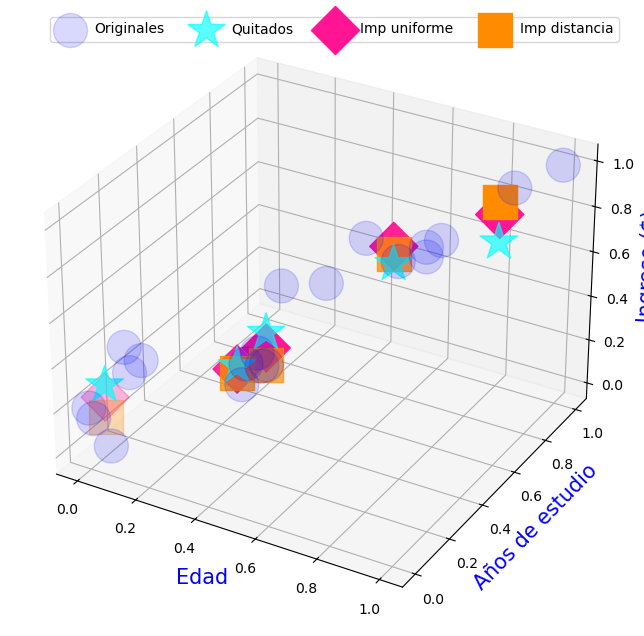

In [11]:
fig = plt.figure(figsize=(8, 8))

### Filtramos todos los valores 'nan' de la tercera columna.
filtro = ~np.isnan(faltantes.T[2])

ax = fig.add_subplot(1, 1, 1, projection="3d")

### Grafos en uno solo.
ax.scatter(escalados.T[0][filtro], 
           escalados.T[1][filtro], 
           escalados.T[2][filtro],
           label="Originales",
           marker="o", c="blue", s=600, alpha=0.15)

ax.scatter(escalados.T[0][~filtro], 
           escalados.T[1][~filtro], 
           escalados.T[2][~filtro],
           label="Quitados",
           marker="*", c="cyan", s=800, alpha=0.65)

ax.scatter(imputados_uni.T[0][~filtro], 
           imputados_uni.T[1][~filtro], 
           imputados_uni.T[2][~filtro],
           label="Imp uniforme",
           marker="D", c="deeppink", s=600)

ax.scatter(imputados_dis.T[0][~filtro], 
           imputados_dis.T[1][~filtro], 
           imputados_dis.T[2][~filtro],
           label="Imp distancia",
           marker="s", c="darkorange", s=600)

ax.set_xlabel("Edad", fontsize=15, color="blue")
ax.set_ylabel("Años de estudio", fontsize=15, color="blue")
ax.set_zlabel("Ingreso ($)", fontsize=15, color="blue")
ax.legend(ncol=4)

plt.show()